# Behavioral Data Exploration

This notebook explores behavioral data from a psychophysical experiment, replicating and extending the analysis from `AnalyzePerformance_simple.m`.

## Overview
The analysis includes:
- Psychometric curve fitting for different stimulus types
- Performance analysis across different angles
- Information theory analysis
- Comparison of different integration models

## Data Structure
The data contains trial information with fields:
- `rat`: Rat ID
- `action`: Response action (0/1)
- `angle`: Stimulus angle (0-90 degrees)
- `hitmiss`: Hit/miss performance (0/1)
- `mod`: Stimulus modality/type
- And many other behavioral parameters


In [16]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import pandas as pd
from scipy.optimize import curve_fit
from scipy import stats
import seaborn as sns
from sklearn.metrics import mutual_info_score
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")


Libraries imported successfully!


In [17]:
# Load the behavioral data
def load_behavior_data(filepath):
    """Load and structure the behavioral data from .mat file"""
    data = scipy.io.loadmat(filepath)
    trial_data = data['TrialNADER'][0, 0]
    
    # Convert to dictionary for easier access
    trial_dict = {}
    for field in trial_data.dtype.names:
        trial_dict[field] = trial_data[field][0].flatten()
    
    # Create a pandas DataFrame for easier manipulation
    df = pd.DataFrame(trial_dict)
    
    # Convert numeric columns to proper types
    numeric_columns = ['rat', 'trialID', 'date', 'oricat', 'action', 'hitmiss', 'penalty', 
                      'penaltyTime', 'samplingTime', 'theta', 'cumPerformance', 'mod', 'angle', 
                      'alpha', 'stimColor', 'RT', 'PT', 'rewardDelay', 'trialReset', 
                      'brightness', 'soa', 'soundQ', 'soundQType']
    
    for col in numeric_columns:
        if col in df.columns:
            # First convert to string, then to numeric to handle any data type issues
            df[col] = pd.to_numeric(df[col].astype(str), errors='coerce')
    
    # Remove rows with NaN values in critical columns
    df = df.dropna(subset=['rat', 'action', 'hitmiss', 'mod', 'angle'])
    
    return df, trial_dict

# Load the data
df, trial_data = load_behavior_data('data/behavior_data.mat')

print(f"Data loaded successfully!")
print(f"Total trials: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())


Data loaded successfully!
Total trials: 1173387
Columns: ['RDT', 'rat', 'trialID', 'date', 'oricat', 'action', 'hitmiss', 'penalty', 'penaltyTime', 'samplingTime', 'theta', 'cumPerformance', 'mod', 'angle', 'alpha', 'stimColor', 'RT', 'PT', 'rewardDelay', 'trialReset', 'brightness', 'soa', 'soundQ', 'soundQType']

First few rows:
   RDT  rat  trialID    date  oricat  action  hitmiss  penalty  penaltyTime  \
0    1    2        1  735193       0       0        1        1            1   
1    2    2        2  735193       0       0        1        1            1   
2    3    2        3  735193       0       0        1        1            1   
3    4    2        4  735193       1       1        1        1            1   
4    5    2        5  735193       1       1        1        1            1   

   samplingTime  ...  alpha  stimColor  RT   PT  rewardDelay  trialReset  \
0             2  ...      5          3   0  0.0            0           0   
1             2  ...      5          3   

=== DATA EXPLORATION ===
Unique rats: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Unique angles: [0, 2, 5, 8, 9, 10, 15, 16, 20, 21, 25, 26, 27, 28, 30, 34, 35, 40, 45, 50, 51, 53, 55, 58, 60, 65, 69, 70, 73, 75, 80, 82, 85, 90, 93, 95, 98, 100, 102, 105, 110, 111, 115, 118, 120, 121, 122, 124, 125, 130, 135, 315, 320, 321, 323, 325, 330, 331, 335, 339, 340, 345, 349, 350, 355]
Unique modalities: [1, 2, 3, 4]
Date range: 735193 to 736711

Missing values per column:
RDT               0
rat               0
trialID           0
date              0
oricat            0
action            0
hitmiss           0
penalty           0
penaltyTime       0
samplingTime      0
theta             0
cumPerformance    0
mod               0
angle             0
alpha             0
stimColor         0
RT                0
PT                0
rewardDelay       0
trialReset        0
brightness        0
soa               0
soundQ            0
soundQType        0
dtype: int64

Data ty

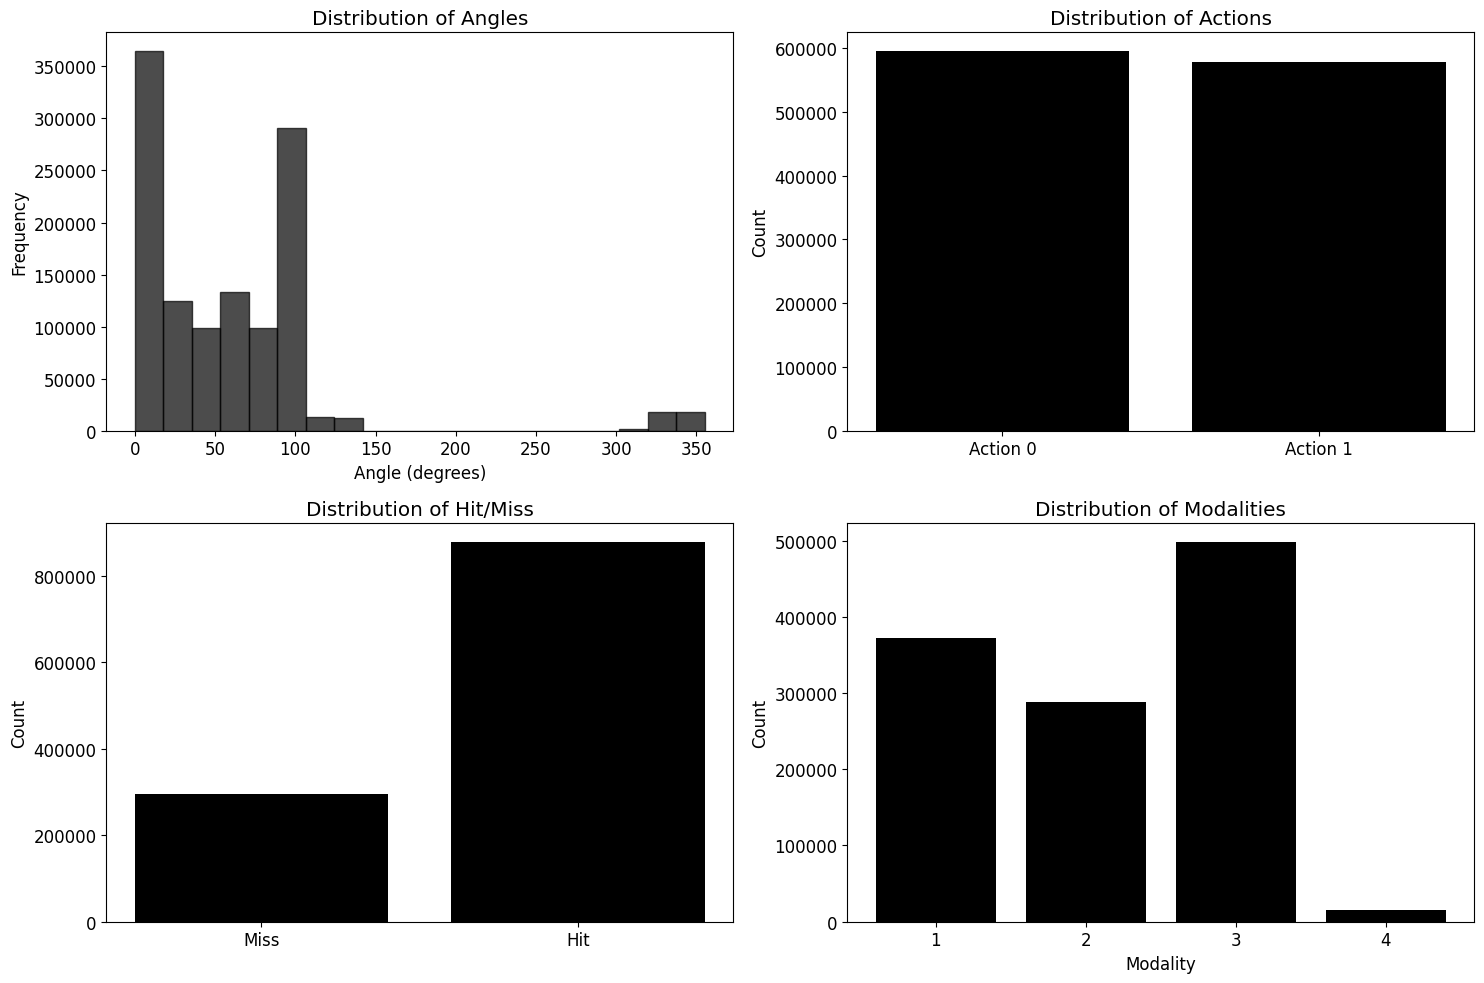

In [19]:
# Data exploration and basic statistics
print("=== DATA EXPLORATION ===")
print(f"Unique rats: {sorted(df['rat'].unique())}")
print(f"Unique angles: {sorted(df['angle'].unique())}")
print(f"Unique modalities: {sorted(df['mod'].unique())}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

# Check for missing values
print(f"\nMissing values per column:")
print(df.isnull().sum())

# Check data types
print(f"\nData types:")
print(df.dtypes)

# Basic statistics for key variables
print(f"\nAngle statistics:")
print(df['angle'].describe())
print(f"\nAction statistics:")
print(df['action'].describe())
print(f"\nHit/Miss statistics:")
print(df['hitmiss'].describe())

# Check for any string values in numeric columns
print(f"\nChecking for string values in numeric columns:")
for col in ['rat', 'action', 'hitmiss', 'mod', 'angle']:
    if col in df.columns:
        string_mask = df[col].astype(str).str.contains('[a-zA-Z]', na=False)
        if string_mask.any():
            print(f"  {col}: {string_mask.sum()} string values found")
            print(f"    Examples: {df[string_mask][col].head().tolist()}")
        else:
            print(f"  {col}: No string values found")

# Plot basic distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Angle distribution
axes[0,0].hist(df['angle'], bins=20, alpha=0.7, edgecolor='black', color='black')
axes[0,0].set_title('Distribution of Angles')
axes[0,0].set_xlabel('Angle (degrees)')
axes[0,0].set_ylabel('Frequency')

# Action distribution
axes[0,1].bar(['Action 0', 'Action 1'], [sum(df['action']==0), sum(df['action']==1)], color='black')
axes[0,1].set_title('Distribution of Actions')
axes[0,1].set_ylabel('Count')

# Hit/Miss distribution
axes[1,0].bar(['Miss', 'Hit'], [sum(df['hitmiss']==0), sum(df['hitmiss']==1)], color='black')
axes[1,0].set_title('Distribution of Hit/Miss')
axes[1,0].set_ylabel('Count')

# Modality distribution
mod_counts = df['mod'].value_counts().sort_index()
axes[1,1].bar(range(len(mod_counts)), mod_counts.values, color='black')
axes[1,1].set_title('Distribution of Modalities')
axes[1,1].set_xlabel('Modality')
axes[1,1].set_ylabel('Count')
axes[1,1].set_xticks(range(len(mod_counts)))
axes[1,1].set_xticklabels(mod_counts.index)

plt.tight_layout()
plt.show()


In [20]:
# Define psychometric functions
def cumulative_gaussian_lapse(x, mu, sigma, gamma, lambda_param):
    """Cumulative Gaussian with lapse rate - matches MATLAB cumulativegaussianLapse.m"""
    # Ensure inputs are numeric arrays
    x = np.asarray(x, dtype=float)
    mu = float(mu)
    sigma = float(sigma)
    gamma = float(gamma)
    lambda_param = float(lambda_param)
    
    # MATLAB: y=gamma+(1-gamma-lambda)*(1/2.*(1+erf((x-mu)./sqrt(2*sigma^2))));
    return gamma + (1 - gamma - lambda_param) * (0.5 * (1 + stats.norm.cdf((x - mu) / sigma)))

def sigma_error(p, n):
    """Binomial confidence interval"""
    # Ensure inputs are numeric
    p = float(p)
    n = float(n)
    if n <= 0:
        return 0
    return np.sqrt(1/n * (p * (1 - p)))

def performance(x):
    """Calculate performance (proportion)"""
    return np.sum(x) / len(x)

print("Psychometric functions defined!")


Psychometric functions defined!


Analyzing 4 rats with stimulus types: [1, 2, 3]
Angle range: 0 to 90 degrees
Data points after filtering (0-90 degrees): 1096428
Reversed rule rats: [6, 7, 14, 15, 16, 17]
Fitting failed for rat 2, stim 1: bad operand type for unary -: 'str'
Fitting failed for rat 2, stim 2: bad operand type for unary -: 'str'
Fitting failed for rat 2, stim 3: bad operand type for unary -: 'str'
Fitting failed for rat 3, stim 1: bad operand type for unary -: 'str'
Fitting failed for rat 3, stim 2: bad operand type for unary -: 'str'
Fitting failed for rat 3, stim 3: bad operand type for unary -: 'str'
Fitting failed for rat 4, stim 1: bad operand type for unary -: 'str'
Fitting failed for rat 4, stim 2: bad operand type for unary -: 'str'
Fitting failed for rat 4, stim 3: bad operand type for unary -: 'str'
Fitting failed for rat 5, stim 1: bad operand type for unary -: 'str'
Fitting failed for rat 5, stim 2: bad operand type for unary -: 'str'
Fitting failed for rat 5, stim 3: bad operand type for una

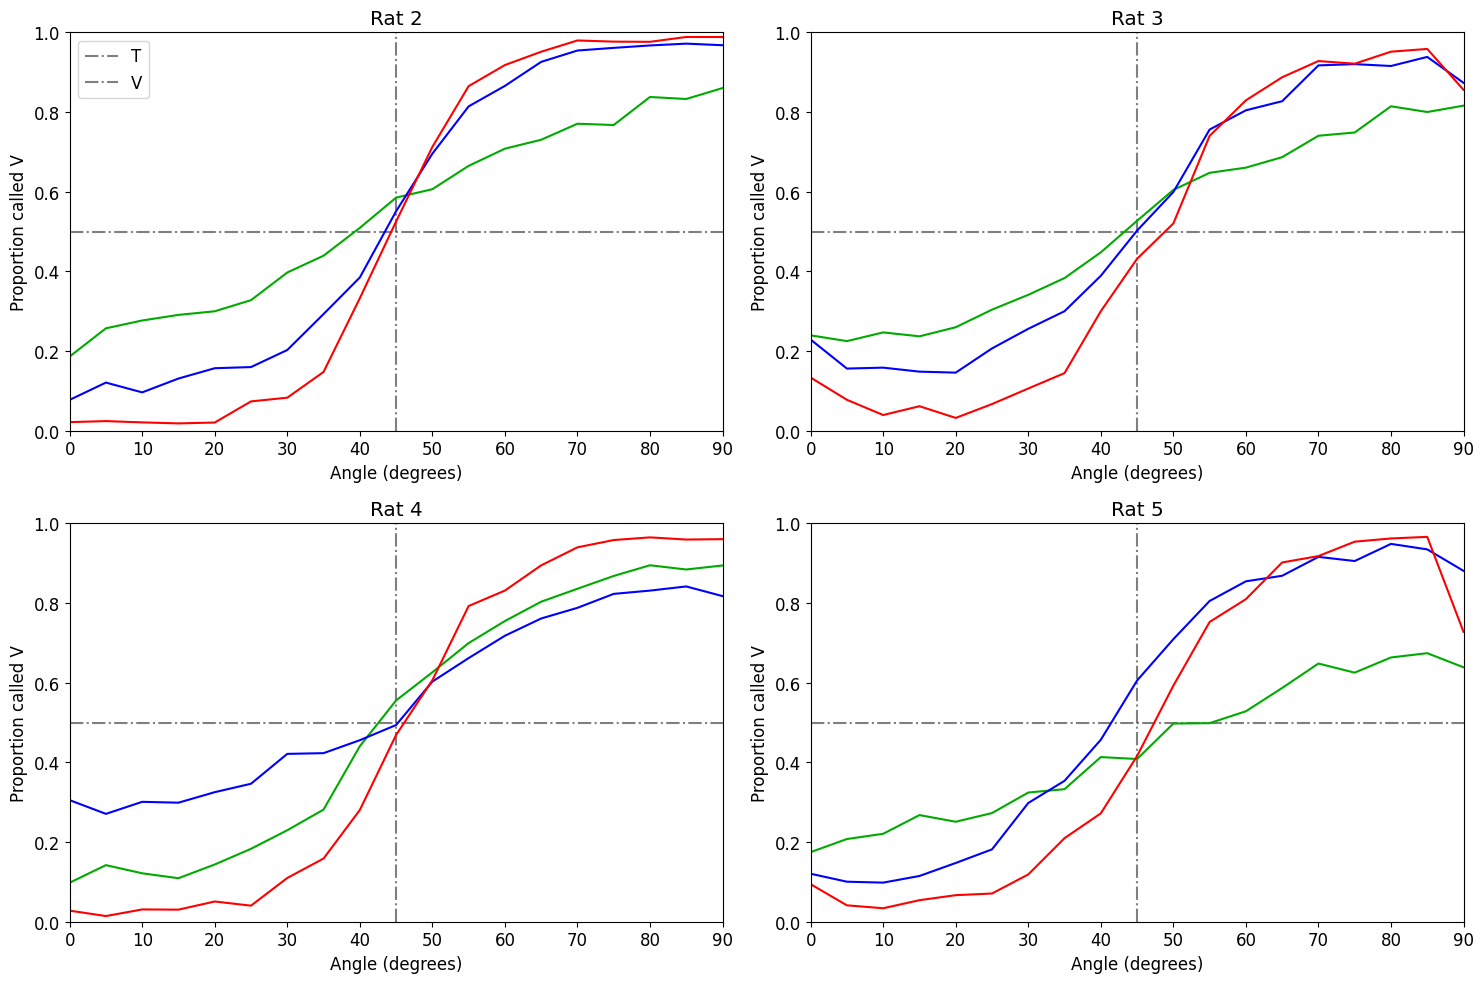

In [23]:
# Psychometric Analysis - Replicating MATLAB analysis
def analyze_psychometric_curves(df, angles, rats, stim_types, rev_rule_rats):
    """Analyze psychometric curves for each rat and stimulus type"""
    
    # Initialize storage
    results = {}
    colors = [[0, 2/3, 0], [0, 0, 1], [1, 0, 0]]  # Green, Blue, Red
    
    # Create figure for psychometric curves - handle different numbers of rats
    n_rats = len(rats)
    if n_rats == 1:
        fig, axes = plt.subplots(1, 1, figsize=(8, 6))
        axes = np.array([[axes]])
    elif n_rats <= 2:
        fig, axes = plt.subplots(1, n_rats, figsize=(15, 6))
        axes = axes.reshape(1, -1)
    elif n_rats <= 4:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    else:
        n_cols = (n_rats + 1) // 2
        fig, axes = plt.subplots(2, n_cols, figsize=(15, 10))
    
    for r, rat_id in enumerate(rats):
        if n_rats == 1:
            ax = axes[0, 0]
        elif n_rats <= 2:
            ax = axes[0, r]
        elif n_rats <= 4:
            ax = axes[r//2, r%2]
        else:
            ax = axes[r//n_cols, r%n_cols]
        
        for st, stim_type in enumerate(stim_types):
            # Filter data for this rat and stimulus type
            mask = (df['rat'] == rat_id) & (df['mod'] == stim_type)
            rat_data = df[mask]
            
            if len(rat_data) == 0:
                continue
                
            # Calculate performance for each angle
            percent_v = []
            errors = []
            data_matrix = []
            
            for i, ang in enumerate(angles):
                angle_mask = rat_data['angle'] == ang
                angle_data = rat_data[angle_mask]
                
                if len(angle_data) > 0:
                    # Ensure action data is numeric
                    action_data = pd.to_numeric(angle_data['action'], errors='coerce')
                    if action_data.isna().any():
                        print(f"Warning: NaN values in action data for rat {rat_id}, stim {stim_type}, angle {ang}")
                        action_data = action_data.dropna()
                    
                    if len(action_data) > 0:
                        perf = performance(action_data)
                        
                        # Apply reversed rule for certain rats - matching MATLAB code
                        if rat_id in rev_rule_rats:
                            perf = 1 - perf  # Flip the performance for reversed rule rats
                        
                        error = sigma_error(perf, len(action_data))
                        
                        percent_v.append(perf)
                        errors.append(error)
                        data_matrix.append([ang, np.sum(action_data), len(action_data)])
                    else:
                        percent_v.append(np.nan)
                        errors.append(np.nan)
                        data_matrix.append([ang, 0, 0])
                else:
                    percent_v.append(np.nan)
                    errors.append(np.nan)
                    data_matrix.append([ang, 0, 0])
            
            percent_v = np.array(percent_v)
            errors = np.array(errors)
            data_matrix = np.array(data_matrix)
            
            # Remove NaN values for fitting
            valid_mask = ~np.isnan(percent_v)
            valid_angles = angles[valid_mask]
            valid_percent = percent_v[valid_mask]
            valid_errors = errors[valid_mask]
            
            if len(valid_angles) < 3:  # Need at least 3 points for fitting
                continue
            
            # Fit psychometric curves using cumulative Gaussian with lapse
            try:
                # Convert to numpy arrays to ensure proper types
                valid_angles = np.asarray(valid_angles, dtype=float)
                valid_percent = np.asarray(valid_percent, dtype=float)
                
                # Check for any non-numeric values
                if np.any(np.isnan(valid_angles)) or np.any(np.isnan(valid_percent)):
                    print(f"Warning: NaN values found for rat {rat_id}, stim {stim_type}")
                    continue
                
                # Check for any infinite values
                if np.any(np.isinf(valid_angles)) or np.any(np.isinf(valid_percent)):
                    print(f"Warning: Infinite values found for rat {rat_id}, stim {stim_type}")
                    continue
                
                # Cumulative Gaussian with lapse - matching MATLAB parameters
                # MATLAB: c4 = [45, 10, 0, 0]; %[mu sigma gamma lambda]
                p0_gaussian = [45, 10, 0, 0]
                bounds_gaussian = ([35, 1, 0, 0], [55, 30, 0.2, 0.2])  # MATLAB bounds
                popt_gaussian, _ = curve_fit(cumulative_gaussian_lapse, valid_angles, valid_percent,
                                           p0=p0_gaussian, bounds=bounds_gaussian, maxfev=2000)
                
                # Plot data points with error bars
                ax.errorbar(valid_angles, valid_percent, valid_errors, 
                           '.', color=colors[st], label=f'Stim {stim_type}')
                
                # Plot fitted curves
                x_fit = np.linspace(0, 90, 100)
                y_gaussian = cumulative_gaussian_lapse(x_fit, *popt_gaussian)
                
                ax.plot(x_fit, y_gaussian, color=colors[st], linewidth=1.5, alpha=0.8)
                
                # Store results
                if rat_id not in results:
                    results[rat_id] = {}
                results[rat_id][stim_type] = {
                    'angles': valid_angles,
                    'performance': valid_percent,
                    'errors': valid_errors,
                    'gaussian_params': popt_gaussian
                }
                
            except Exception as e:
                print(f"Fitting failed for rat {rat_id}, stim {stim_type}: {e}")
                continue
        
        # Format subplot
        ax.axhline(y=0.5, color='k', linestyle='-.', alpha=0.5)
        ax.axvline(x=45, color='k', linestyle='-.', alpha=0.5)
        ax.set_xlim(0, 90)
        ax.set_ylim(0, 1)
        ax.set_title(f'Rat {rat_id}')
        ax.set_xlabel('Angle (degrees)')
        ax.set_ylabel('Proportion called V')
        
        if r == 0:
            ax.legend(['T', 'V', 'VT'])
    
    plt.tight_layout()
    plt.show()
    
    return results

# Run the analysis - matching MATLAB code structure
angles = np.arange(0, 91, 5)  # 0:5:90 - matches MATLAB
rats = sorted(df['rat'].unique())
# Remove rats 8, 14, 15, 17-21 as in MATLAB code
rats = [r for r in rats if r not in [8, 14, 15, 17, 18, 19, 20, 21]]
stim_types = [1, 2, 3]  # Only first 3 stimulus types (ignore control=4)

# Define reversed rule rats - matching MATLAB: rev_rule = ismember(rats, [6,7,14:17])
rev_rule_rats = [6, 7, 14, 15, 16, 17]

# Filter data to only include angles 0-90 degrees for psychometric analysis
df_filtered = df[(df['angle'] >= 0) & (df['angle'] <= 90)].copy()

# For debugging, let's start with just a few rats
rats_subset = rats[:4]  # First 4 rats

print(f"Analyzing {len(rats_subset)} rats with stimulus types: {stim_types}")
print(f"Angle range: {angles[0]} to {angles[-1]} degrees")
print(f"Data points after filtering (0-90 degrees): {len(df_filtered)}")
print(f"Reversed rule rats: {rev_rule_rats}")

results = analyze_psychometric_curves(df_filtered, angles, rats_subset, stim_types, rev_rule_rats)
